# Titanic dataset from Kaggle — a classic for EDA practice.

In [33]:
#pip install seaborn --upgrade

In [34]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [35]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load Dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
#Data Sourcing
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
# tolist --> to get a quick overview of the features available


Shape of dataset: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [37]:
#Data Cleaning
# Check missing values
count_missing = df.isnull().sum()
#returns a coung of missing (NaN) values for each column
print(count_missing)

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())
#median is robust to outliers
#preserve the central tendency without being skewed by extreme values

# Drop Cabin due to high missingness
df.drop('Cabin', axis=1, inplace=True)

# Fill Embarked with mode (safe assignment)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#mode is ideal for categorical columns
#keeps the distribution consistent with majority of the data


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


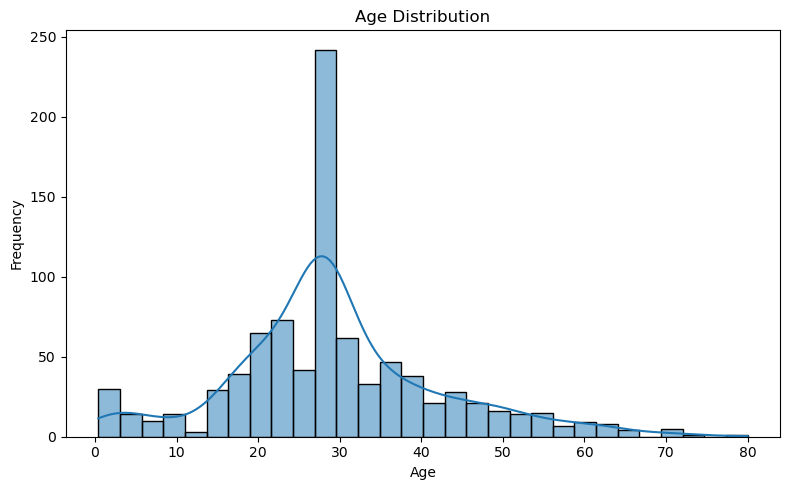

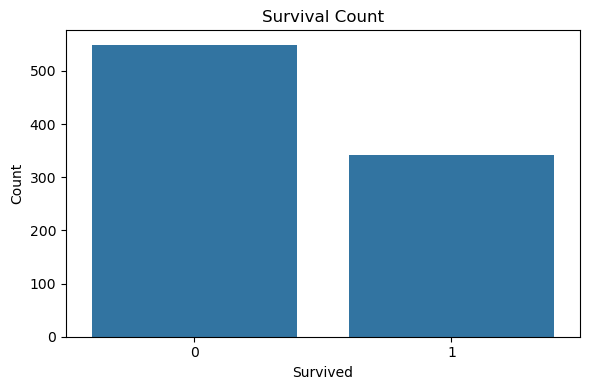

In [38]:
# Univariate Analysis

# Distribution of Age
plt.figure(figsize=(8, 5))  # Start a new figure
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()

# Survival Count
plt.figure(figsize=(6, 4))  # Start another new figure
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.tight_layout()


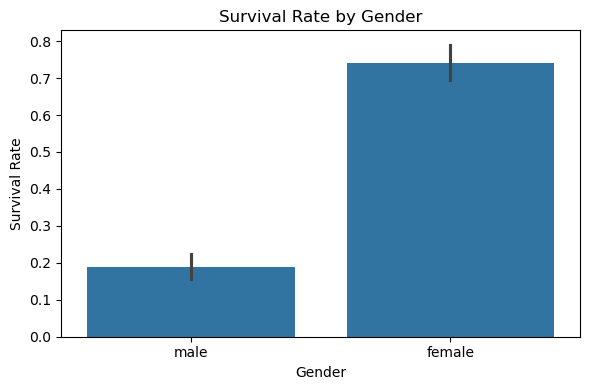

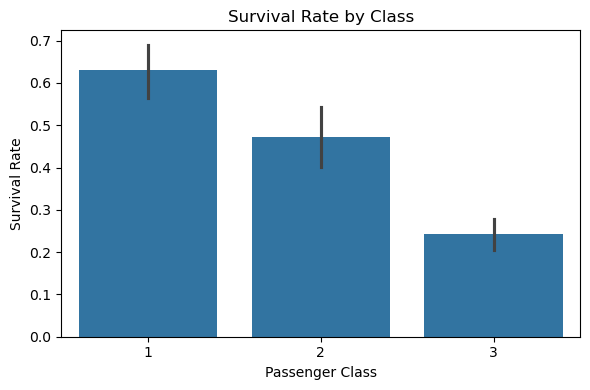

In [39]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')
plt.tight_layout()

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.tight_layout()


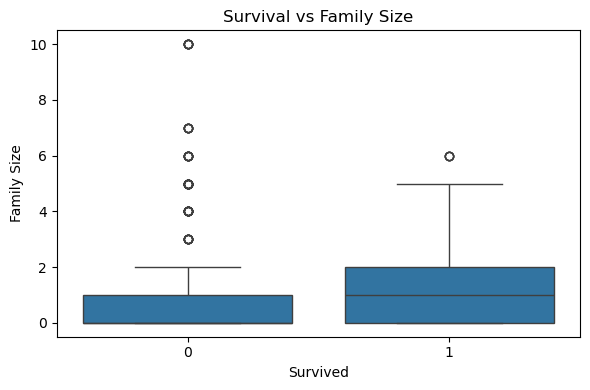

In [45]:
#Derived Metrics
# Create Family Size
df['FamilySize'] = df['SibSp'] + df['Parch']

plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='FamilySize', data=df)
plt.title('Survival vs Family Size')
plt.xlabel('Survived')
plt.ylabel('Family Size')
plt.tight_layout()


In [41]:
#discuss and check if below statements are true or false
#Insights from Case Study
#Women had a higher survival rate than men.

#First-class passengers were more likely to survive.

#Smaller families had better survival odds.